# BME 574 — Project 1 starter
### Five steps. Five cells for you to write. Everything else is done.

The data is already assembled into a matrix, the split is already made, the plots are already
written. **Your job is the five cells marked `TODO`** — about fifteen lines of code in total.

That is deliberate. Assembling a data matrix from raw PhysioNet records is a week of work on its
own and teaches you file formats, not linear algebra. You will do that in later assignments. Here
the point is to understand what the matrix *is*, decompose it correctly, and use it to predict
something — without accidentally cheating.

---

### What you hand in

1. **This notebook**, run top to bottom, with all five `TODO` cells filled and every `check`
   passing.
2. **A one-page memo** (`REPORT.md`) answering the six questions in Step 5. One page. Not five.
3. **`AI_USE.md`** — which tools you used and for what. Course policy: disclose, verify,
   understand.

No separate report, no extra figures beyond the three this notebook makes.

### Before you start

If you have not used NumPy, do **`BME574_NumPy_primer.ipynb`** first. It takes about 40 minutes
and covers exactly the eleven operations this notebook uses. Starting here without it will cost
you far more than 40 minutes.

### The one idea to hold on to

> Anything learned from data — a mean, a scaler, a set of components — is a **model parameter**,
> and must be computed from the training rows only. If your components have seen the test set,
> your test score is fiction. Steps 2 and 3 are where this is won or lost.

---
## Step 0 · Load your data bundle

Your track's data comes as a single `.npz` file containing everything already prepared:

| Key | What it is |
|---|---|
| `X` | The data matrix. **Rows are observations, columns are features.** |
| `y` | The label for each row — what you are predicting |
| `subject` | Which person each row came from |
| `train_idx`, `test_idx` | The split, already made by subject |
| `feature_shape` | How to reshape one row back into its natural form for plotting |
| `class_names` | Human-readable names for the labels |

Bundles are produced by `make_track_bundle.py`; your instructor will give you the file.

Set `BUNDLE` to your track's file. If it is missing, the cell builds a small synthetic demo so
you can run everything immediately and check your code works — but **a submission using the demo
data scores zero**, so swap in your real track before you hand in.

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

BUNDLE = 'bundles/pneumonia.npz'      # <-- set this to your track's file
SEED = 0
rng = np.random.default_rng(SEED)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

# progress flags — each TODO sets its own to True once its checks pass
ok1 = ok2 = ok3 = ok4 = False

In [4]:
def _make_demo(path, n_subj=40, per_subj=12, side=16, seed=0):
    """Builds a small stand-in bundle so this notebook runs before your data arrives."""
    g = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:side, 0:side] / side
    X, y, subj = [], [], []
    for s in range(n_subj):
        cls = s % 2
        # the class effect is real but SMALL next to between-subject variation,
        # so the demo behaves like real data rather than being trivially separable
        cy = 0.45 + 0.13 * cls + g.normal(0, .06)
        cx = 0.50 + g.normal(0, .07)
        width = 0.11 + 0.02 * g.normal()
        for _ in range(per_subj):
            jy, jx = g.normal(0, .03, 2)
            blob = np.exp(-((yy - cy - jy) ** 2 + (xx - cx - jx) ** 2) / (2 * width ** 2))
            gain = g.uniform(0.5, 1.8)                 # nuisance: overall brightness
            X.append((gain * blob + 0.11 * g.normal(size=(side, side))).reshape(-1))
            y.append(cls); subj.append(s)
    X = np.array(X); y = np.array(y); subj = np.array(subj)
    te_s = g.choice(n_subj, size=n_subj // 3, replace=False)   # split BY SUBJECT
    te = np.where(np.isin(subj, te_s))[0]
    tr = np.where(~np.isin(subj, te_s))[0]
    np.savez(path, X=X, y=y, subject=subj, train_idx=tr, test_idx=te,
             feature_shape=np.array([side, side]),
             class_names=np.array(['class A', 'class B']),
             track='DEMO (not real data)', plot_kind='image')


if not os.path.exists(BUNDLE):
    BUNDLE = 'demo_track.npz'
    if not os.path.exists(BUNDLE):
        _make_demo(BUNDLE)

D = np.load(BUNDLE, allow_pickle=True)
X, y, subject = D['X'].astype(float), D['y'], D['subject']
train_idx, test_idx = D['train_idx'], D['test_idx']
feature_shape = tuple(D['feature_shape'])
class_names = [str(c) for c in D['class_names']]
TRACK = str(D['track'])
PLOT_KIND = str(D['plot_kind']) if 'plot_kind' in D.files else 'image'


def show_row(ax, row, title=None):
    """Draw one observation the right way up for this track."""
    if PLOT_KIND == 'curve':
        ax.plot(np.asarray(row).ravel(), lw=1.0)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        ax.imshow(np.asarray(row).reshape(feature_shape), cmap='gray')
        ax.axis('off')
    if title:
        ax.set_title(title, fontsize=9)

IS_DEMO = 'DEMO' in TRACK
print('=' * 60)
print(f'  track: {TRACK}')
if IS_DEMO:
    print('  ^ synthetic stand-in. Swap in your real track before submitting.')
print('=' * 60)

  track: Chest X-ray — pneumonia (MedMNIST PneumoniaMNIST, official split)


---
## Step 1 · Look at your data before you touch it

Nothing to write here. Run it, read the output, and answer the first two memo questions from
what you see.

In [5]:
n, p = X.shape
print(f'X          {X.shape}    <- {n} observations, {p} features each')
print(f'y          {y.shape}    classes: {dict(zip(class_names, np.bincount(y)))}')
print(f'subjects   {len(np.unique(subject))}')
print(f'train/test {len(train_idx)} / {len(test_idx)}')
print()

# --- the number your model has to beat -------------------------------
majority = np.bincount(y[test_idx]).max() / len(test_idx)
print(f'MAJORITY-CLASS BASELINE: {majority:.3f}')
print('Always predicting the commonest class already scores this. Beat it or you have nothing.')
print()

# --- the split really is by subject ----------------------------------
shared = np.intersect1d(subject[train_idx], subject[test_idx])
print(f'subjects appearing in BOTH train and test: {len(shared)}  (must be 0)')
assert len(shared) == 0
assert len(np.intersect1d(train_idx, test_idx)) == 0
print('Split is clean.')

X          (5332, 784)    <- 5332 observations, 784 features each
y          (5332,)    classes: {'normal': np.int64(1448), 'pneumonia': np.int64(3884)}
subjects   5332
train/test 4708 / 624

MAJORITY-CLASS BASELINE: 0.625
Always predicting the commonest class already scores this. Beat it or you have nothing.

subjects appearing in BOTH train and test: 0  (must be 0)
Split is clean.


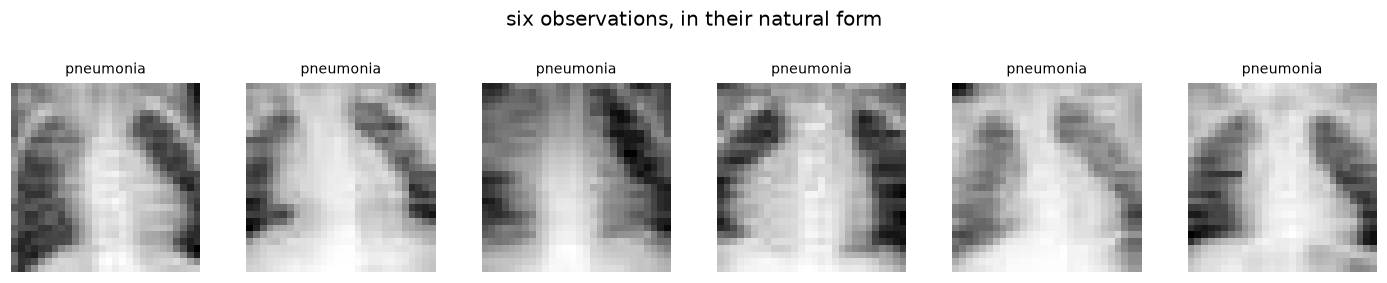

In [12]:
# what does one observation look like?
fig, axes = plt.subplots(1, 6, figsize=(13, 2.4))
for ax, i in zip(axes, rng.choice(len(X), 6, replace=False)):
    show_row(ax, X[i], class_names[y[i]])
fig.suptitle('six observations, in their natural form', y=1.06)
fig.tight_layout(); plt.show()

---
## Step 2 · **TODO 1** — centre and decompose, on training rows only

Fill in three lines.

1. `mu` — the mean of each feature, computed from **`X[train_idx]` only**.
2. `Xc` — the training rows with `mu` subtracted.
3. `U, s, Vt` — the SVD of `Xc`. Pass `full_matrices=False`.

> Why training rows only? Because `mu` and `Vt` are things you *learned*. Learning them from the
> test set is like revising from the exam paper. The check below will catch you.

*Primer sections 7, 8 and 11 if you need them.*

In [27]:
# # ---- TODO 1 ----------------------------------------------------------
# mu = None          # per-feature mean of the TRAINING rows       (shape: (p,))
# Xc = None          # training rows, centred                      (shape: (n_train, p))
# U, s, Vt = None, None, None      # np.linalg.svd(..., full_matrices=False)
# # ----------------------------------------------------------------------

mu = np.mean(X[train_idx], axis=0)
Xc = X[train_idx] - mu
Xc.shape
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)

def check(name, cond, hint=''):
    print(f'  {"OK  " if cond else "NOT YET"}  {name}')
    if not cond and hint: print(f'           hint: {hint}')
    return cond

ok1 = all([
    check('mu has one value per feature',
          isinstance(mu, np.ndarray) and mu.shape == (p,),
          'X[train_idx].mean(axis=0)  — axis=0 makes the ROW axis disappear'),
    check('mu used training rows only',
          isinstance(mu, np.ndarray) and mu.shape == (p,)
          and np.allclose(mu, X[train_idx].mean(axis=0)),
          'if you used all of X, this fails — that is the point'),
    check('Xc is the centred training block',
          isinstance(Xc, np.ndarray) and Xc.shape == (len(train_idx), p)
          and np.allclose(Xc, X[train_idx] - X[train_idx].mean(axis=0)),
          'X[train_idx] - mu   (broadcasting does the repeating for you)'),
    check('Vt has components as ROWS',
          isinstance(Vt, np.ndarray) and Vt.shape[1] == p,
          'np.linalg.svd returns Vt already transposed; component 1 is Vt[0]'),
])
print()
print('Step 2 complete.' if ok1 else 'Fix the lines above before continuing.')

  OK    mu has one value per feature
  OK    mu used training rows only
  OK    Xc is the centred training block
  OK    Vt has components as ROWS

Step 2 complete.


### Figure 1 — the singular value spectrum *(written for you)*

How fast the singular values fall tells you how low-dimensional your data really is. Where they
flatten out, the rest is noise.

In [7]:
if not ok1:
    raise SystemExit('Finish TODO 1 first — Figure 1 needs the singular values.')

energy = np.cumsum(s ** 2) / np.sum(s ** 2)
k95 = int(np.searchsorted(energy, 0.95) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].semilogy(s, lw=1.3)
ax[0].axvline(k95, color='crimson', ls='--', label=f'95% of energy at k={k95}')
ax[0].set(xlabel='component', ylabel='singular value', title='Figure 1a — spectrum')
ax[0].legend(fontsize=9)
ax[1].plot(np.arange(1, len(energy) + 1), energy, lw=1.3)
ax[1].axhline(0.95, color='crimson', ls='--')
ax[1].set(xlabel='number of components', ylabel='cumulative energy',
          title='Figure 1b — variance explained', xlim=(0, min(120, len(energy))))
fig.tight_layout(); plt.show()

print(f'{p} features compress to about {k95} components at 95% energy.')

SystemExit: Finish TODO 1 first — Figure 1 needs the singular values.

/Users/ivan/miniconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Figure 2 — what the components look like *(written for you)*

Each component is a pattern over your features, so it can be drawn in the same form as your data.
**Look at these properly.** Give each one a caption in your memo. If the honest caption is
"overall brightness", write that — the leading components are very often a nuisance rather than
the signal you care about.

In [ ]:
if not ok1:
    raise SystemExit('Finish TODO 1 first — Figure 2 needs the components.')

fig, axes = plt.subplots(1, 7, figsize=(14, 2.4))
show_row(axes[0], mu, 'mean')
for i in range(6):
    if PLOT_KIND == 'curve':
        axes[i + 1].plot(Vt[i], lw=1.0, color='#c0392b')
        axes[i + 1].axhline(0, color='k', lw=.5, alpha=.4)
        axes[i + 1].set_xticks([]); axes[i + 1].set_yticks([])
    else:
        axes[i + 1].imshow(Vt[i].reshape(feature_shape), cmap='RdBu_r')
        axes[i + 1].axis('off')
    axes[i + 1].set_title(f'comp {i + 1}', fontsize=9)
fig.suptitle('Figure 2 — the mean and the first six components', y=1.06)
fig.tight_layout(); plt.show()

---
## Step 3 · **TODO 2** — project into `k` dimensions

Turn every observation from `p` numbers into `k` numbers, by measuring it against the components.

Complete the function body. Two lines:

```python
Z = (X_rows - mu) @ Vt[:k].T
```

Use the **same `mu` and the same `Vt`** for training and test rows. That is the whole discipline.

*Shape check: `(rows, p) @ (p, k)` → `(rows, k)`. Primer section 9.*

In [ ]:
def project(X_rows, k):
    """Map rows of X into the k-dimensional component space."""
    # ---- TODO 2 ------------------------------------------------------
    Z = None
    # ------------------------------------------------------------------
    return Z


if not ok1:
    raise SystemExit('Finish TODO 1 first — this step needs mu and Vt.')

K = 20
Z_train = project(X[train_idx], K)
Z_test = project(X[test_idx], K)

ok2 = all([
    check('training projection has the right shape',
          isinstance(Z_train, np.ndarray) and Z_train.shape == (len(train_idx), K),
          '(X_rows - mu) @ Vt[:k].T'),
    check('test projection has the right shape',
          isinstance(Z_test, np.ndarray) and Z_test.shape == (len(test_idx), K)),
    check('projection matches the reference',
          isinstance(Z_train, np.ndarray) and Z_train.shape == (len(train_idx), K)
          and np.allclose(Z_train, (X[train_idx] - mu) @ Vt[:K].T),
          'did you remember to subtract mu first?'),
])
print()
print(f'each observation is now {K} numbers instead of {p}.' if ok2 else 'Fix TODO 2.')

---
## Step 4 · **TODO 3** — classify by nearest centroid

This is exactly the face-recognition method from class. Two pieces:

**`fit_centroids`** — the average position of each class in the component space. One line with a
list comprehension, or a plain `for` loop if you prefer:

```python
cents = np.stack([Z[y_rows == c].mean(axis=0) for c in classes])
```

**`predict`** — for each new point, whichever centroid is closest wins. The distance array is
given; you supply the last step with `np.argmin`.

*Primer sections 3 and 10.*

In [ ]:
def fit_centroids(Z, y_rows):
    classes = np.unique(y_rows)
    # ---- TODO 3a -----------------------------------------------------
    cents = None       # shape (n_classes, k) — the mean point of each class
    # ------------------------------------------------------------------
    return classes, cents


def predict(Z, classes, cents):
    d = ((Z[:, None, :] - cents[None, :, :]) ** 2).sum(axis=-1)   # (n_rows, n_classes)
    # ---- TODO 3b -----------------------------------------------------
    winner = None      # index of the SMALLEST distance in each row
    # ------------------------------------------------------------------
    if winner is None:
        return None
    return classes[winner]


if not ok2:
    raise SystemExit('Finish TODO 2 first — this step needs the projection.')

classes, cents = fit_centroids(Z_train, y[train_idx])
pred = predict(Z_test, classes, cents) if cents is not None else None

ref_c = np.stack([Z_train[y[train_idx] == c].mean(axis=0) for c in np.unique(y[train_idx])])
ok3 = all([
    check('centroids: one point per class',
          isinstance(cents, np.ndarray) and cents.shape == (len(classes), K)
          and np.allclose(cents, ref_c),
          'select the rows of Z where y_rows == c, then average them with axis=0'),
    check('predictions: one label per test row',
          isinstance(pred, np.ndarray) and pred.shape == (len(test_idx),)
          and set(np.unique(pred)) <= set(classes),
          'np.argmin(d, axis=1) — the class axis is the one that disappears'),
])

if ok3:
    print()
    print(f'accuracy at k={K}: {(pred == y[test_idx]).mean():.3f}'
          f'   (majority baseline {majority:.3f})')

---
## Step 5 · **TODO 4** — does `k` matter, and did any of this help?

Fill the loop body: project the training and test rows at this `k`, fit centroids, predict, and
store the accuracy. Four lines, all of which you have already written above.

The two baselines underneath are written for you and cost nothing, because your pipeline is a
function:

- **raw features** — the same classifier with no SVD at all. If it ties you, the decomposition
  bought speed and interpretability but not accuracy. That is a real result; report it.
- **shuffled labels** — the same pipeline on nonsense. It must collapse to roughly the majority
  rate. If it does not, something is leaking and your headline number is not real.

In [ ]:
K_GRID = [1, 2, 3, 5, 8, 12, 20, 35, 60, 100]
K_GRID = [k for k in K_GRID if k <= min(len(train_idx) - 1, p)]

if not ok3:
    raise SystemExit('Finish TODO 3 first — the sweep reuses your classifier.')

acc = []
for k in K_GRID:
    # ---- TODO 4 ------------------------------------------------------
    Ztr = None         # project the training rows at this k
    Zte = None         # project the test rows at this k
    cl, ce = None, None   # fit centroids on Ztr and y[train_idx]
    p_k = None         # predict on Zte
    # ------------------------------------------------------------------
    if p_k is None:
        raise SystemExit('TODO 4 is not filled in yet.')
    acc.append((p_k == y[test_idx]).mean())
    print(f'  k={k:4d}   accuracy={acc[-1]:.3f}')

ok4 = check('accuracy computed for every k',
            len(acc) == len(K_GRID) and all(0 <= a <= 1 for a in acc))

In [ ]:
if not ok4:
    raise SystemExit('Finish TODO 4 first.')

# ---- baselines, written for you --------------------------------------
cl_r, ce_r = fit_centroids(X[train_idx], y[train_idx])          # no SVD at all
raw_acc = (predict(X[test_idx], cl_r, ce_r) == y[test_idx]).mean()

# nonsense labels, averaged over a few shuffles so the number is stable
Ztr20, Zte20 = project(X[train_idx], 20), project(X[test_idx], 20)
shuf_runs = []
for _ in range(5):
    cl_s, ce_s = fit_centroids(Ztr20, rng.permutation(y[train_idx]))
    shuf_runs.append((predict(Zte20, cl_s, ce_s) == y[test_idx]).mean())
shuf_acc = float(np.mean(shuf_runs))

best_i = int(np.argmax(acc))
K_STAR, best = K_GRID[best_i], acc[best_i]

print(f'{"majority class":32s} {majority:.3f}')
print(f'{"shuffled labels (control)":32s} {shuf_acc:.3f}')
print(f'{"raw features, no SVD":32s} {raw_acc:.3f}')
print(f'{f"nearest-centroid, k={K_STAR}":32s} {best:.3f}   <- your result')
print()
for label, cond in [('beats the majority class', best > majority),
                    ('beats shuffled labels', best > shuf_acc + 0.02),
                    ('shuffled control near chance', abs(shuf_acc - 0.5) < 0.25
                     if len(classes) == 2 else shuf_acc < majority + 0.10)]:
    print(f'  {"OK  " if cond else "LOOK AGAIN"}  {label}')

### Figure 3 — accuracy against `k` *(written for you)*

In [ ]:
if not ok4:
    raise SystemExit('Finish TODO 4 first — Figure 3 needs the sweep.')

plt.figure(figsize=(7, 4.4))
plt.semilogx(K_GRID, acc, 'o-', lw=1.6, label='nearest centroid on components')
plt.axhline(majority, color='crimson', ls='--', lw=1.2, label='majority class')
plt.axhline(raw_acc, color='seagreen', ls='-.', lw=1.2, label='raw features, no SVD')
plt.axhline(shuf_acc, color='grey', ls=':', lw=1.2, label='shuffled labels')
plt.plot(K_STAR, best, '*', ms=17, color='navy', zorder=5)
plt.annotate(f'k={K_STAR}', (K_STAR, best), textcoords='offset points', xytext=(8, -16))
plt.xlabel('number of components k'); plt.ylabel('test accuracy')
plt.title('Figure 3 — accuracy vs. k, against the baselines')
plt.ylim(-0.03, 1.03); plt.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

---
## Step 6 · **TODO 5** — the memo

Write `REPORT.md`, **one page**, answering these six questions. Short answers. Complete sentences,
no padding.

1. **What is one row of your matrix, and what are you predicting?** Two sentences. Name the
   clinical or physiological decision your label stands in for.
2. **What do the first three components look like?** Caption each from Figure 2. If a component
   is brightness, position, or some other nuisance, say so — that is a finding, not a failure.
3. **What `k` would you use and why?** Point at Figure 3. "The highest one" is not a reason;
   "accuracy plateaus after k=12 and smaller is cheaper and less prone to overfitting" is.
4. **How does your result compare to all three baselines?** Give the four numbers. If the
   no-SVD baseline ties you, say what the decomposition bought you instead.
5. **Where could this pipeline have cheated, and how do you know it did not?** Name the specific
   line where `mu` and `Vt` were fitted, and say which rows they saw.
6. **What would you need to trust this clinically?** One paragraph. More subjects? Better labels?
   A different target? Be concrete.

> A project reporting "we expected the components to separate the classes and they did not, here
> is the evidence" is a complete project and will be graded well. A negative result you can defend
> beats a positive one you cannot.

In [ ]:
# final check — everything above should be OK before you submit
steps = {'Step 2  centre and decompose': ok1,
         'Step 3  project': ok2,
         'Step 4  classify': ok3,
         'Step 5  sweep k': ok4}
for name, done in steps.items():
    print(f'  {"OK  " if done else "NOT YET"}  {name}')
print()
if all(steps.values()):
    print('All code steps pass. Write REPORT.md and AI_USE.md and you are done.')
else:
    print('Some steps are incomplete — scroll up to the ones marked NOT YET.')
if IS_DEMO:
    print()
    print('REMINDER: this ran on the synthetic demo bundle, not your real track.')

---
## If you get stuck

| Symptom | Almost always |
|---|---|
| `ValueError: matmul: ... mismatch` | A transpose. Print every shape and compare to the comment. |
| `check` says shape `(p,)` expected, got `(n,)` | Wrong `axis=`. It names the axis that disappears. |
| Accuracy is suspiciously perfect | Something leaked, or a feature encodes the label. Investigate before celebrating. |
| Shuffled-label control scores well | Real leakage. Check that `mu` and `Vt` came from `X[train_idx]`. |
| Everything is `nan` | A class with no rows in the training split, or a divide by zero in centring. |
| Accuracy sits exactly at the majority rate | The classifier is predicting one class for everything. Look at Figure 2 — the components may be pure nuisance. |

Come to office hours with the failing cell and its printed shapes. That is usually a two-minute
conversation.